Task 1 -- GPT-style LLM from scratch (character-level), TinyStories.
Author: Charvee Saraiya

Architecture (own design, deliberately different from teammate's, no prebuilt
Transformer/attention modules):
  - Post-LayerNorm Transformer blocks: x = LN(x + Attn(x)); x = LN(x + FFN(x))
  - Manually implemented scaled dot-product multi-head self-attention with a causal mask
  - ReLU feed-forward network (not GELU)
  - Learned token + positional embeddings, NO weight tying (separate LM head)
  - Config: n_layer=6, n_head=4, n_embd=96, block_size=96, dropout=0.15 (deeper & narrower
    than teammate's 4-layer/128-dim model)
  - AdamW with linear warmup -> linear decay (not cosine)
  - Independent data slice: takes the SECOND 110K-character window of the shared corpus

In [1]:
import json
import math
import os
import time

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

### Config

In [2]:
SEED = 7
BLOCK_SIZE = 96
N_LAYER = 6
N_HEAD = 4
N_EMBD = 96
DROPOUT = 0.15
BATCH_SIZE = 48
N_EPOCHS = 60
PEAK_LR = 5e-4
WARMUP_FRAC = 0.1
TRAIN_CHARS = 100_000
VAL_CHARS = 10_000
DATA_OFFSET = 150_000  # Charvee Saraiya's independent slice (non-overlapping with Ishan's 0:110_000)

if os.environ.get("SMOKE_TEST") == "1":  # fast correctness check before a GPU Lab session
    N_EPOCHS = 2
    TRAIN_CHARS = 20_000
    VAL_CHARS = 2_000

try:
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:  # running inside a Jupyter notebook (nbconvert cwd = notebook's dir)
    HERE = os.path.abspath(".")
MEMBER_DIR = os.path.dirname(HERE)
DATA_PATH = os.path.join(MEMBER_DIR, "..", "data", "tinystories_raw.txt")
CKPT_DIR = os.path.join(MEMBER_DIR, "checkpoints")
OUT_DIR = os.path.join(MEMBER_DIR, "outputs")
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


### 1.1 Data preprocessing -- char-level tokenizer + own train/val split

In [3]:
with open(DATA_PATH, "r", encoding="utf-8") as f:
    full_text = f.read()

slice_text = full_text[DATA_OFFSET: DATA_OFFSET + TRAIN_CHARS + VAL_CHARS]
train_text = slice_text[:TRAIN_CHARS]
val_text = slice_text[TRAIN_CHARS: TRAIN_CHARS + VAL_CHARS]
assert len(train_text) == TRAIN_CHARS and len(val_text) == VAL_CHARS

chars = sorted(list(set(full_text)))
vocab_size = len(chars)
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

def encode(s):
    return [char_to_idx[c] for c in s]

def decode(ids):
    return "".join(idx_to_char[i] for i in ids)

train_ids = torch.tensor(encode(train_text), dtype=torch.long)
val_ids = torch.tensor(encode(val_text), dtype=torch.long)
print(f"Vocab size: {vocab_size} | train chars: {len(train_ids)} | val chars: {len(val_ids)}")

with open(os.path.join(OUT_DIR, "vocab.json"), "w") as f:
    json.dump({"char_to_idx": char_to_idx, "idx_to_char": idx_to_char}, f)


def get_batch(split):
    data = train_ids if split == "train" else val_ids
    ix = torch.randint(0, len(data) - BLOCK_SIZE - 1, (BATCH_SIZE,))
    x = torch.stack([data[i:i + BLOCK_SIZE] for i in ix])
    y = torch.stack([data[i + 1:i + BLOCK_SIZE + 1] for i in ix])
    return x.to(device), y.to(device)


STEPS_PER_EPOCH = max(1, (TRAIN_CHARS // BLOCK_SIZE) // BATCH_SIZE)
TOTAL_STEPS = STEPS_PER_EPOCH * N_EPOCHS
WARMUP_STEPS = max(1, int(TOTAL_STEPS * WARMUP_FRAC))

Vocab size: 93 | train chars: 100000 | val chars: 10000


### 1.2 GPT model implementation from scratch

In [4]:
class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_head = n_head
        self.head_dim = n_embd // n_head
        self.key = nn.Linear(n_embd, n_embd)
        self.query = nn.Linear(n_embd, n_embd)
        self.value = nn.Linear(n_embd, n_embd)
        self.proj = nn.Linear(n_embd, n_embd)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)
        mask = torch.tril(torch.ones(block_size, block_size)).view(1, 1, block_size, block_size)
        self.register_buffer("mask", mask)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        q = self.query(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = self.value(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.attn_drop(att)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_drop(self.proj(y))


class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    """Post-LayerNorm transformer block (LN applied AFTER the residual add)."""

    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        self.attn = CausalSelfAttention(n_embd, n_head, block_size, dropout)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ffn = FeedForward(n_embd, dropout)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = self.ln1(x + self.attn(x))
        x = self.ln2(x + self.ffn(x))
        return x


class GPT(nn.Module):
    def __init__(self, vocab_size, n_embd, n_head, n_layer, block_size, dropout):
        super().__init__()
        self.block_size = block_size
        self.tok_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([Block(n_embd, n_head, block_size, dropout) for _ in range(n_layer)])
        self.head = nn.Linear(n_embd, vocab_size)  # separate, untied head
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))
        for block in self.blocks:
            x = block(x)
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, greedy=False):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            if greedy:
                next_id = torch.argmax(probs, dim=-1, keepdim=True)
            else:
                next_id = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_id], dim=1)
        return idx


model = GPT(vocab_size, N_EMBD, N_HEAD, N_LAYER, BLOCK_SIZE, DROPOUT).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameter count: {n_params:,}")

Parameter count: 698,205


### 1.3 Training with LR warmup + linear decay

In [5]:
optimizer = torch.optim.AdamW(model.parameters(), lr=PEAK_LR, weight_decay=0.01)


def lr_at_step(step):
    if step < WARMUP_STEPS:
        return PEAK_LR * (step + 1) / WARMUP_STEPS
    progress = (step - WARMUP_STEPS) / max(1, TOTAL_STEPS - WARMUP_STEPS)
    return PEAK_LR * max(0.0, 1.0 - progress)


@torch.no_grad()
def estimate_loss(eval_iters=20):
    model.eval()
    out = {}
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        correct, total = 0, 0
        for k in range(eval_iters):
            x, y = get_batch(split)
            logits, loss = model(x, y)
            losses[k] = loss.item()
            preds = logits.argmax(dim=-1)
            correct += (preds == y).sum().item()
            total += y.numel()
        out[split] = {"loss": losses.mean().item(), "acc": correct / total}
    model.train()
    return out


history = {"epoch": [], "train_loss": [], "val_loss": [], "val_acc": [], "grad_norm": [], "lr": []}
nan_count = 0
grad_norms = []

log_path = os.path.join(MEMBER_DIR, "raw_train_log.txt")
log_f = open(log_path, "w")

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

t_start = time.time()
step = 0
tokens_processed = 0
for epoch in range(1, N_EPOCHS + 1):
    for _ in range(STEPS_PER_EPOCH):
        lr = lr_at_step(step)
        for g in optimizer.param_groups:
            g["lr"] = lr

        x, y = get_batch("train")
        logits, loss = model(x, y)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()

        total_norm = 0.0
        for p in model.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item() ** 2
        total_norm = total_norm ** 0.5
        grad_norms.append(total_norm)
        if math.isnan(loss.item()) or math.isnan(total_norm):
            nan_count += 1

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        step += 1
        tokens_processed += BATCH_SIZE * BLOCK_SIZE

    metrics = estimate_loss()
    history["epoch"].append(epoch)
    history["train_loss"].append(metrics["train"]["loss"])
    history["val_loss"].append(metrics["val"]["loss"])
    history["val_acc"].append(metrics["val"]["acc"])
    history["grad_norm"].append(total_norm)
    history["lr"].append(lr)

    line = (f"epoch {epoch:3d}/{N_EPOCHS} | train_loss {metrics['train']['loss']:.4f} | "
            f"val_loss {metrics['val']['loss']:.4f} | val_acc {metrics['val']['acc']:.4f} | "
            f"lr {lr:.2e} | grad_norm {total_norm:.3f}")
    print(line)
    log_f.write(line + "\n")
    log_f.flush()

train_time_sec = time.time() - t_start
train_tokens_per_sec = tokens_processed / train_time_sec
peak_mem_mb = (torch.cuda.max_memory_allocated() / 1e6) if torch.cuda.is_available() else 0.0
log_f.write(f"\nTotal training time: {train_time_sec:.2f}s | tokens/sec: {train_tokens_per_sec:.1f} | "
            f"peak_mem_MB: {peak_mem_mb:.1f} | nan_count: {nan_count}\n")

epoch   1/60 | train_loss 3.7237 | val_loss 3.7013 | val_acc 0.1845 | lr 8.33e-05 | grad_norm 3.301


epoch   2/60 | train_loss 3.2508 | val_loss 3.2435 | val_acc 0.1861 | lr 1.67e-04 | grad_norm 0.669


epoch   3/60 | train_loss 3.0296 | val_loss 3.0180 | val_acc 0.2353 | lr 2.50e-04 | grad_norm 0.973


epoch   4/60 | train_loss 2.7014 | val_loss 2.7005 | val_acc 0.2912 | lr 3.33e-04 | grad_norm 1.217


epoch   5/60 | train_loss 2.5163 | val_loss 2.5259 | val_acc 0.3042 | lr 4.17e-04 | grad_norm 0.818


...

epoch  57/60 | train_loss 1.6502 | val_loss 1.7403 | val_acc 0.4734 | lr 2.82e-05 | grad_norm 0.835


epoch  58/60 | train_loss 1.6500 | val_loss 1.7345 | val_acc 0.4760 | lr 1.90e-05 | grad_norm 0.812


epoch  59/60 | train_loss 1.6418 | val_loss 1.7229 | val_acc 0.4781 | lr 9.70e-06 | grad_norm 0.831


epoch  60/60 | train_loss 1.6534 | val_loss 1.7178 | val_acc 0.4804 | lr 4.41e-07 | grad_norm 0.798


86

### Loss curve plot

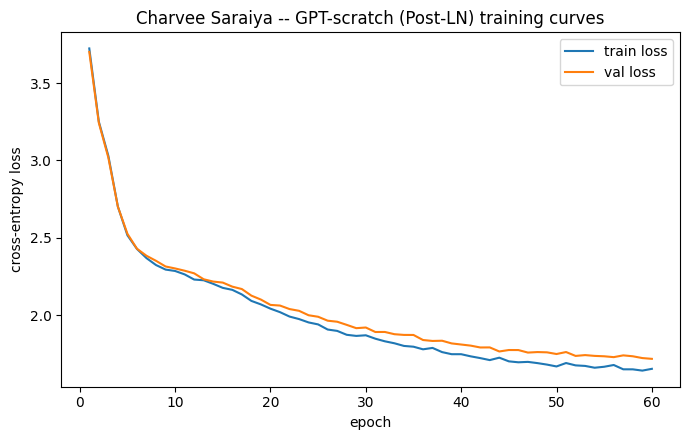

In [6]:
plt.figure(figsize=(7, 4.5))
plt.plot(history["epoch"], history["train_loss"], label="train loss")
plt.plot(history["epoch"], history["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("Charvee Saraiya -- GPT-scratch (Post-LN) training curves")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "loss_curve.png"), dpi=130)
plt.show()

### 1.3.5 Text generation

In [7]:
def generate_text(prompt, max_new_tokens=300, temperature=0.8, greedy=False):
    idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    out = model.generate(idx, max_new_tokens=max_new_tokens, temperature=temperature, greedy=greedy)
    return decode(out[0].tolist())


t0 = time.time()
samples = []
prompts = ["Once upon a time", "The little dog", "One day, a girl"]
for p in prompts:
    samples.append({"prompt": p, "temperature_0.8": generate_text(p, temperature=0.8)})
    samples.append({"prompt": p, "greedy": generate_text(p, greedy=True)})
gen_time = time.time() - t0
gen_chars = sum(len(s.get("temperature_0.8", s.get("greedy", ""))) for s in samples)
gen_tokens_per_sec = gen_chars / gen_time

with open(os.path.join(OUT_DIR, "generated_samples.json"), "w") as f:
    json.dump(samples, f, indent=2)

for s in samples:
    print("-" * 60)
    print(s)

------------------------------------------------------------
{'prompt': 'Once upon a time', 'temperature_0.8': 'Once upon a time the nexcic arecint. Bolintt umick boundant witnt the shis yared a and ndarked He up tho gat, che rear. The wit list shat, he best her and of t fo a and man he pryant the to prareld and and now play it the in ta way qunt o this git rige and."\n\n<STORY_SEP>\nOnce anply ay and a coxe git the geat cogar!'}
------------------------------------------------------------
{'prompt': 'Once upon a time', 'greedy': 'Once upon a time the the was the she san the said, the was said so she wared and he she he par and the shere and the had some and and and the was she was shaid the was so and and the sto the starte the she wand the so she she said and the was so so and the said hered and and the was he was she wand had to the was a'}
------------------------------------------------------------
{'prompt': 'The little dog', 'temperature_0.8': 'The little doger. It mom fell. Loh

### Generation-diversity metrics (distinct-n, repeated 4-gram rate)

In [8]:
def ngrams(seq, n):
    return [tuple(seq[i:i + n]) for i in range(len(seq) - n + 1)]


all_gen_text = "".join(s.get("temperature_0.8", s.get("greedy", "")) for s in samples)
distinct = {}
for n in [1, 2, 3]:
    grams = ngrams(all_gen_text, n)
    distinct[f"distinct_{n}"] = len(set(grams)) / max(1, len(grams))

grams4 = ngrams(all_gen_text, 4)
repeated_4gram_rate = 1 - (len(set(grams4)) / max(1, len(grams4)))

### Final metrics report

In [9]:
final_train_loss = history["train_loss"][-1]
final_val_loss = history["val_loss"][-1]
perplexity = math.exp(final_val_loss)
bpc = final_val_loss / math.log(2)
gen_gap = final_val_loss - final_train_loss

metrics_row = {
    "member": "Charvee Saraiya",
    "architecture": "Post-LN Transformer, untied head, ReLU FFN",
    "n_layer": N_LAYER, "n_head": N_HEAD, "n_embd": N_EMBD, "block_size": BLOCK_SIZE,
    "dropout": DROPOUT, "epochs": N_EPOCHS, "batch_size": BATCH_SIZE, "peak_lr": PEAK_LR,
    "train_loss": final_train_loss,
    "val_loss": final_val_loss,
    "perplexity": perplexity,
    "bits_per_char": bpc,
    "generalization_gap": gen_gap,
    "top1_next_char_acc": history["val_acc"][-1],
    "distinct_1": distinct["distinct_1"],
    "distinct_2": distinct["distinct_2"],
    "distinct_3": distinct["distinct_3"],
    "repeated_4gram_rate": repeated_4gram_rate,
    "grad_norm_mean": sum(grad_norms) / len(grad_norms),
    "grad_norm_max": max(grad_norms),
    "nan_count": nan_count,
    "param_count": n_params,
    "train_tokens_per_sec": train_tokens_per_sec,
    "gen_tokens_per_sec": gen_tokens_per_sec,
    "peak_memory_MB": peak_mem_mb,
    "total_training_time_sec": train_time_sec,
}

import csv
metrics_csv_path = os.path.join(MEMBER_DIR, "metrics_report.csv")
with open(metrics_csv_path, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(metrics_row.keys()))
    w.writeheader()
    w.writerow(metrics_row)

with open(os.path.join(OUT_DIR, "history.json"), "w") as f:
    json.dump(history, f, indent=2)

torch.save(model.state_dict(), os.path.join(CKPT_DIR, "gpt_charvee_saraiya.pt"))
log_f.close()

print("\n=== FINAL METRICS (Charvee Saraiya) ===")
for k, v in metrics_row.items():
    print(f"{k}: {v}")


=== FINAL METRICS (Charvee Saraiya) ===
member: Charvee Saraiya
architecture: Post-LN Transformer, untied head, ReLU FFN
n_layer: 6
n_head: 4
n_embd: 96
block_size: 96
dropout: 0.15
epochs: 60
batch_size: 48
peak_lr: 0.0005
train_loss: 1.6533520221710205
val_loss: 1.717804193496704
perplexity: 5.572279373594494
bits_per_char: 2.4782675911759604
generalization_gap: 0.0644521713256836
top1_next_char_acc: 0.48037109375
distinct_1: 0.025396825396825397
distinct_2: 0.13922710428798307
distinct_3: 0.3225635593220339
repeated_4gram_rate: 0.5241123476417594
grad_norm_mean: 0.9826603122385577
grad_norm_max: 13.979009299497738
nan_count: 0
param_count: 698205
train_tokens_per_sec: 31748.696247646734
gen_tokens_per_sec: 501.0402620425607
peak_memory_MB: 0.0
total_training_time_sec: 182.87617087364197
